# Chroma key extraction lab

This notebook is meant to debug why chroma-key removal fails on generated game-art layers.

It focuses on the typical failure modes:
- the chroma background is not perfectly uniform;
- anti-aliased borders mix object color with the chroma color;
- shadows or semi-transparent pixels near edges are wrongly classified;
- a fixed RGB threshold is too brittle;
- using a color present in the scene, such as green in vegetation, destroys useful pixels.

The recommended key color for the Bariloche bus-stop layers is **pure magenta**: `#FF00FF`.

In [22]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Change this to the layer you want to inspect.
# Example:
# IMAGE_PATH = Path("parada_rural_en_estilo_ilustrado.png")
#IMAGE_PATH = Path("data/bariloche_bus_stop/01.png")
IMAGE_PATH = Path("data/julia/julia.png")

# Chroma key color in RGB.
KEY_RGB = np.array([240, 255, 212], dtype=np.uint8)

assert IMAGE_PATH.exists(), f"File not found: {IMAGE_PATH.resolve()}"

## Load image

(1254, 1254, 3)


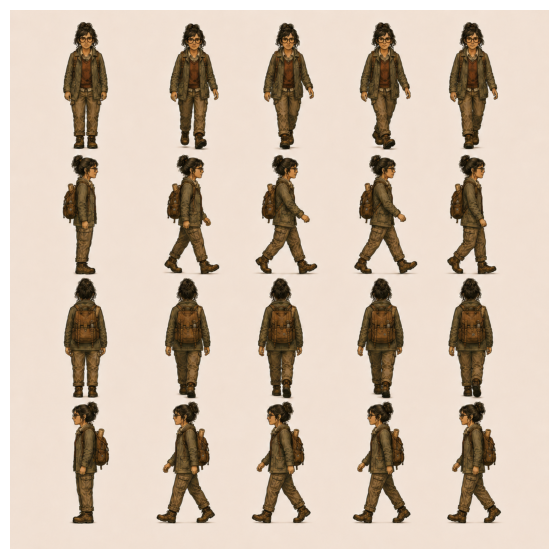

In [23]:
def imread_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

img = imread_rgb(IMAGE_PATH)
h, w = img.shape[:2]
print(img.shape)

plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis("off");

In [24]:
img[0:5,0:5].mean(axis=1)

array([[240. , 225. , 212.2],
       [239.8, 224.8, 212.6],
       [240.4, 225.8, 212.6],
       [240.4, 225.2, 212.2],
       [240.8, 225.6, 213. ]])

## First diagnostic: how uniform is the chroma background?

This checks how far every pixel is from the expected key color in RGB space.  
If the background is truly flat `#FF00FF`, most background pixels should have distance near zero.

RGB distance statistics
p  0: 17.26
p  1: 26.02
p  5: 28.18
p 25: 30.02
p 50: 31.02
p 75: 32.16
p 95: 342.42
p 99: 374.81
p100: 409.35


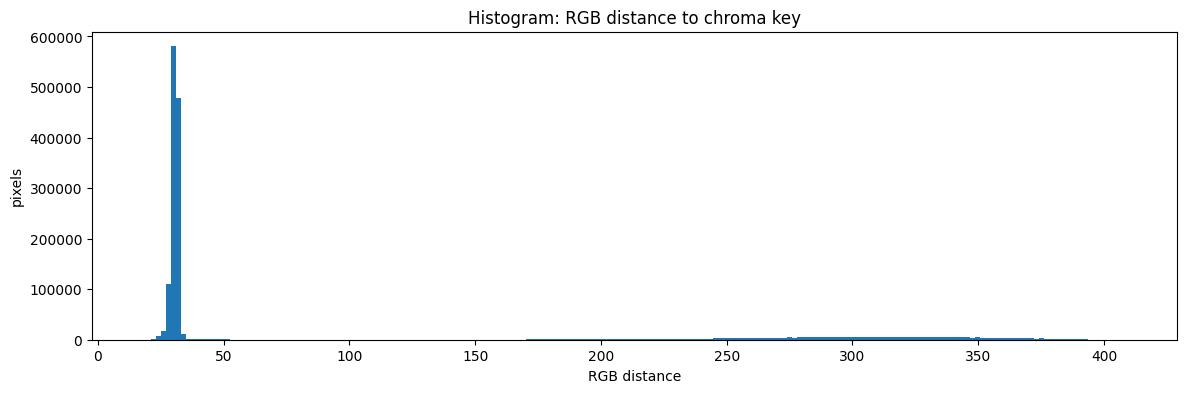

In [25]:
key = KEY_RGB.astype(np.float32)
img_f = img.astype(np.float32)

rgb_dist = np.linalg.norm(img_f - key[None, None, :], axis=2)

print("RGB distance statistics")
for p in [0, 1, 5, 25, 50, 75, 95, 99, 100]:
    print(f"p{p:>3}: {np.percentile(rgb_dist, p):.2f}")

plt.figure(figsize=(14, 4))
plt.hist(rgb_dist.ravel(), bins=200)
plt.title("Histogram: RGB distance to chroma key")
plt.xlabel("RGB distance")
plt.ylabel("pixels");

## Baseline method: RGB distance threshold

This is the simplest method: pixels close to magenta are background.  
It often fails near anti-aliased borders because border pixels are neither pure magenta nor pure object color.

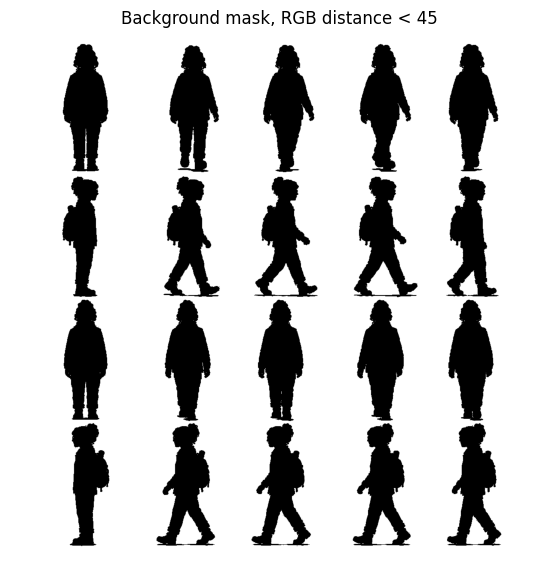

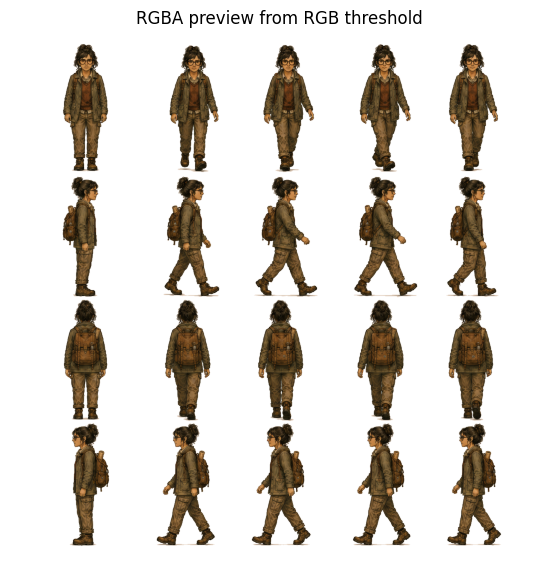

In [26]:
# Tune this first.
RGB_THRESHOLD = 45

bg_mask_rgb = rgb_dist < RGB_THRESHOLD
fg_mask_rgb = ~bg_mask_rgb

plt.figure(figsize=(14, 7))
plt.imshow(bg_mask_rgb, cmap="gray")
plt.title(f"Background mask, RGB distance < {RGB_THRESHOLD}")
plt.axis("off");

rgba_rgb = np.dstack([img, (fg_mask_rgb.astype(np.uint8) * 255)])
plt.figure(figsize=(14, 7))
plt.imshow(rgba_rgb)
plt.title("RGBA preview from RGB threshold")
plt.axis("off");

## HSV diagnostic

HSV can be useful because the key color is strongly saturated and has a distinctive hue.  
However, hue becomes unstable near very dark or very bright pixels, so use it together with saturation/value constraints.

KEY HSV: [ 40  43 255]


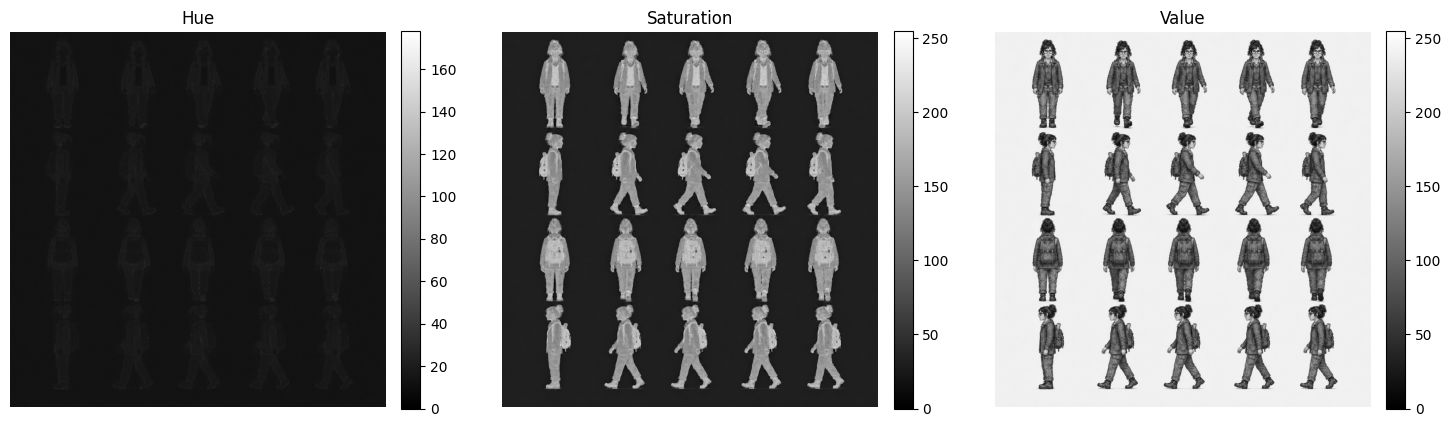

In [27]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]

# OpenCV hue is 0..179. Magenta #FF00FF is around hue 150.
key_hsv = cv2.cvtColor(np.uint8([[KEY_RGB]]), cv2.COLOR_RGB2HSV)[0, 0]
print("KEY HSV:", key_hsv)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, channel, title in zip(axes, [H, S, V], ["Hue", "Saturation", "Value"]):
    im = ax.imshow(channel, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## HSV keying

Useful when the background is almost magenta but not exactly `#FF00FF`.

For magenta:
- hue should be near 150 in OpenCV HSV,
- saturation should be high,
- value should be high.

This method may still produce halos if the generated image creates blended edges.

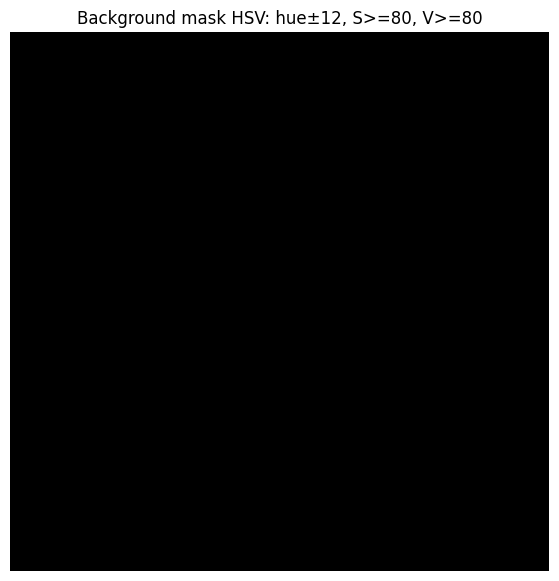

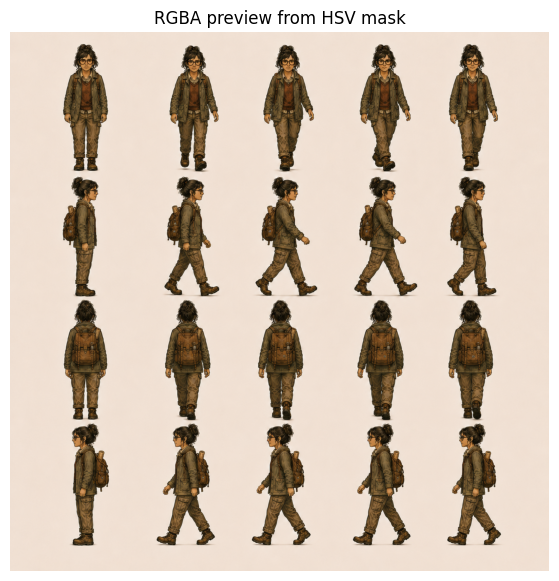

In [28]:
KEY_H = int(key_hsv[0])

# Tune these.
HUE_TOL = 12
MIN_S = 80
MIN_V = 80

# Circular hue distance in OpenCV's 0..179 hue space.
hue_dist = np.minimum(np.abs(H.astype(np.int16) - KEY_H), 180 - np.abs(H.astype(np.int16) - KEY_H))

bg_mask_hsv = (hue_dist <= HUE_TOL) & (S >= MIN_S) & (V >= MIN_V)
fg_mask_hsv = ~bg_mask_hsv

plt.figure(figsize=(14, 7))
plt.imshow(bg_mask_hsv, cmap="gray")
plt.title(f"Background mask HSV: hue±{HUE_TOL}, S>={MIN_S}, V>={MIN_V}")
plt.axis("off");

rgba_hsv = np.dstack([img, (fg_mask_hsv.astype(np.uint8) * 255)])
plt.figure(figsize=(14, 7))
plt.imshow(rgba_hsv)
plt.title("RGBA preview from HSV mask")
plt.axis("off");

## Combine RGB and HSV masks

A conservative background mask can reduce false removals.  
For chroma-key extraction, false positives are often worse than false negatives: a remaining pink fringe is easier to post-process than missing object detail.

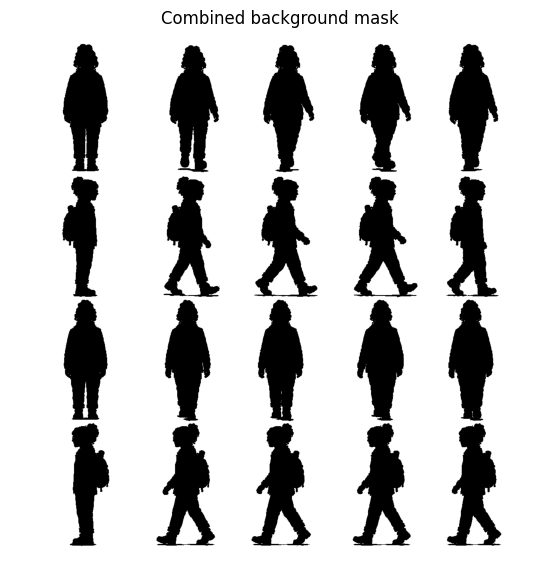

In [29]:
# Candidate strategy:
# background if it is close in RGB OR it strongly matches magenta in HSV.
bg_mask = bg_mask_rgb | bg_mask_hsv

plt.figure(figsize=(14, 7))
plt.imshow(bg_mask, cmap="gray")
plt.title("Combined background mask")
plt.axis("off");

## Mask cleanup

Common cleanup operations:
- **opening** removes small isolated background detections inside the object;
- **closing** fills small holes in the background mask;
- **dilation** expands the background mask, useful to remove a chroma halo;
- **erosion** preserves the object edge but may leave halo.

For foliage and irregular edges, be careful: too much morphology destroys detail.

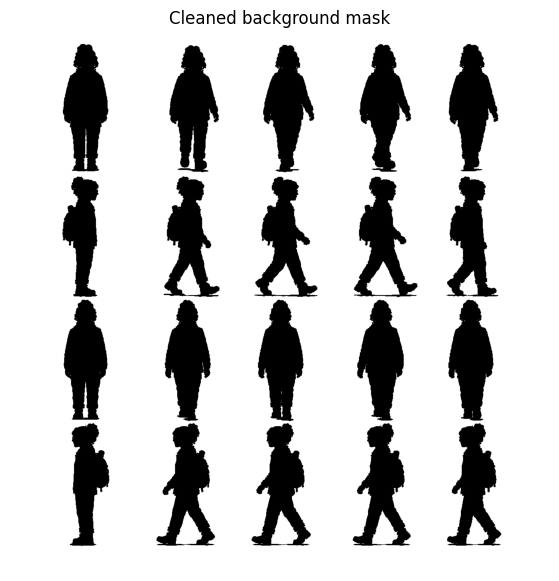

In [30]:
# Tune these.
OPEN_K = 0       # 0 disables
CLOSE_K = 0      # 0 disables
DILATE_K = 1     # useful for removing magenta fringe
ERODE_K = 0

def morph_mask(mask, open_k=0, close_k=0, dilate_k=0, erode_k=0):
    m = mask.astype(np.uint8) * 255
    if open_k > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (open_k, open_k))
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k)
    if close_k > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (close_k, close_k))
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k)
    if dilate_k > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_k, dilate_k))
        m = cv2.dilate(m, k)
    if erode_k > 0:
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (erode_k, erode_k))
        m = cv2.erode(m, k)
    return m > 0

bg_clean = morph_mask(bg_mask, OPEN_K, CLOSE_K, DILATE_K, ERODE_K)
fg_clean = ~bg_clean

plt.figure(figsize=(14, 7))
plt.imshow(bg_clean, cmap="gray")
plt.title("Cleaned background mask")
plt.axis("off");

## Soft alpha from distance transform

A binary mask creates jagged edges.  
This step creates a gradual alpha around the boundary.

Interpretation:
- `FEATHER_PX`: width of the transition zone.
- Too low: jagged edge.
- Too high: ghostly semi-transparent borders.

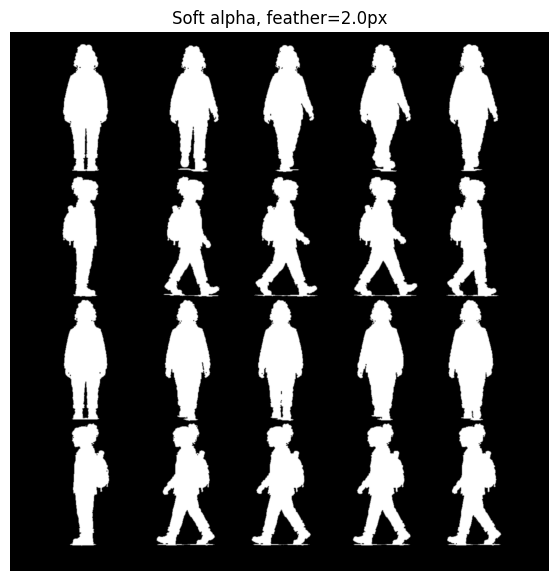

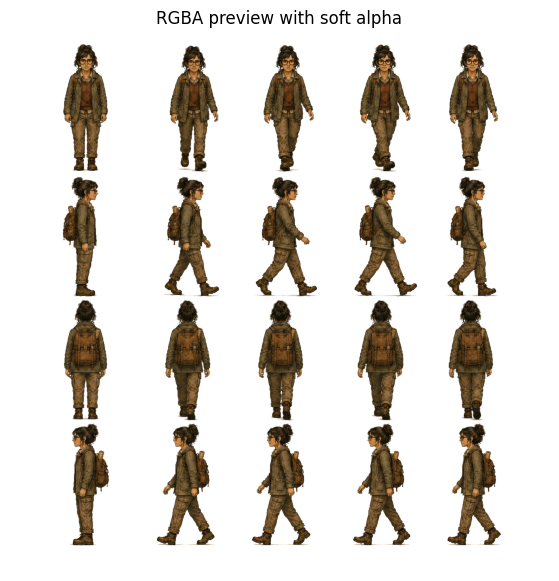

In [31]:
FEATHER_PX = 2.0

# Distance to nearest background pixel, computed inside foreground.
fg_u8 = fg_clean.astype(np.uint8)
dist_inside_fg = cv2.distanceTransform(fg_u8, cv2.DIST_L2, 3)

alpha = np.clip(dist_inside_fg / FEATHER_PX, 0, 1)
alpha[bg_clean] = 0.0

rgba_soft = np.dstack([img, (alpha * 255).astype(np.uint8)])

plt.figure(figsize=(14, 7))
plt.imshow(alpha, cmap="gray")
plt.title(f"Soft alpha, feather={FEATHER_PX}px")
plt.axis("off");

plt.figure(figsize=(14, 7))
plt.imshow(rgba_soft)
plt.title("RGBA preview with soft alpha")
plt.axis("off");

## Optional: despill / magenta fringe reduction

Anti-aliased edge pixels may contain magenta contamination.  
A simple despill reduces magenta dominance in semi-transparent edge pixels.

This is intentionally conservative. It targets only pixels whose alpha is between 0 and 1.

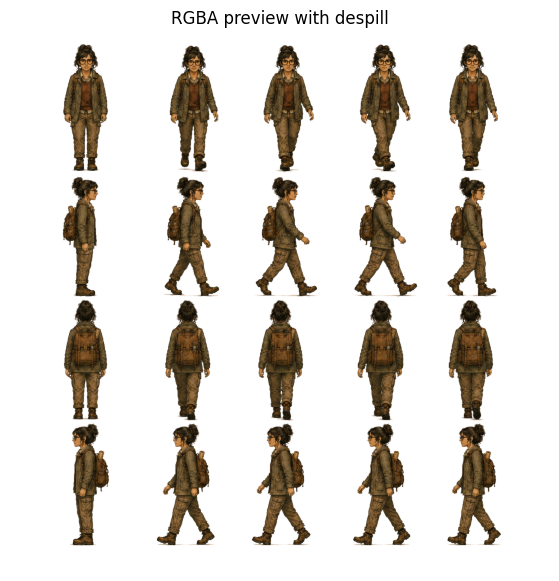

In [32]:
DESPILL_STRENGTH = 0.7  # 0 disables, 1 strong

rgb = img.astype(np.float32) / 255.0
r, g, b = rgb[..., 0], rgb[..., 1], rgb[..., 2]

# Magenta excess relative to green.
magenta_excess = np.maximum(0, np.minimum(r, b) - g)

edge = (alpha > 0.0) & (alpha < 1.0)
correction = DESPILL_STRENGTH * magenta_excess * edge

rgb_despill = rgb.copy()
rgb_despill[..., 0] = np.clip(rgb_despill[..., 0] - correction, 0, 1)
rgb_despill[..., 2] = np.clip(rgb_despill[..., 2] - correction, 0, 1)
rgb_despill[..., 1] = np.clip(rgb_despill[..., 1] + correction * 0.25, 0, 1)

rgba_despill = np.dstack([(rgb_despill * 255).astype(np.uint8), (alpha * 255).astype(np.uint8)])

plt.figure(figsize=(14, 7))
plt.imshow(rgba_despill)
plt.title("RGBA preview with despill")
plt.axis("off");

## Preview over test backgrounds

A good extraction should look acceptable over several backgrounds.  
Use this to catch halos that are invisible over a similar color.

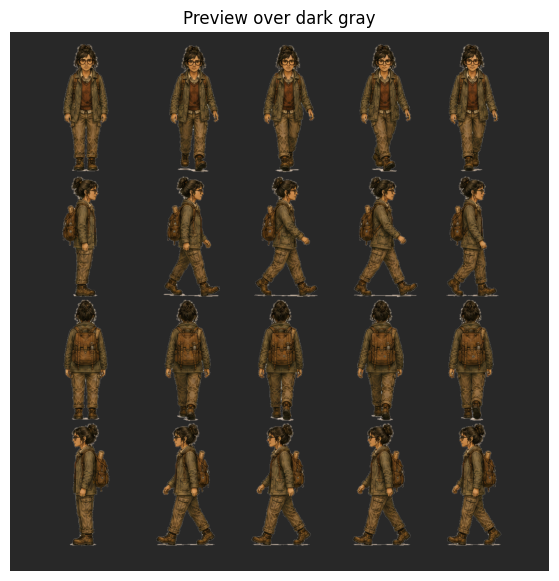

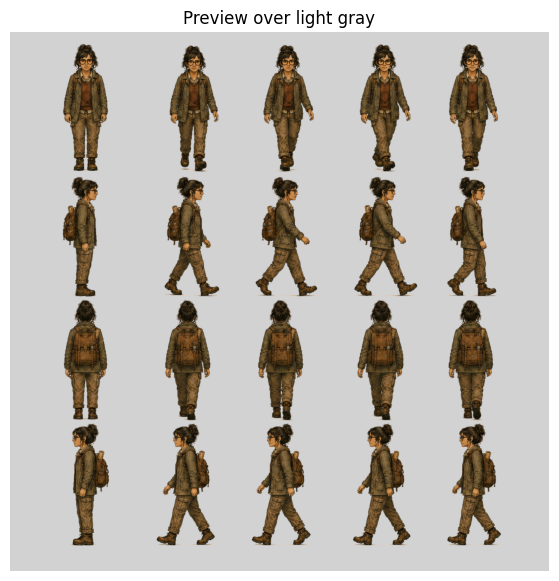

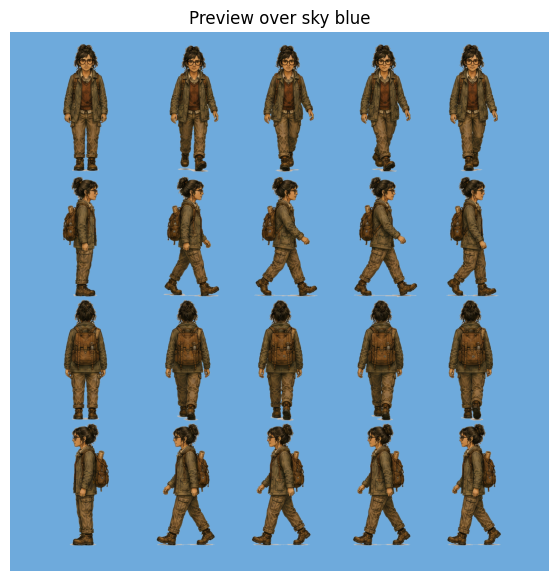

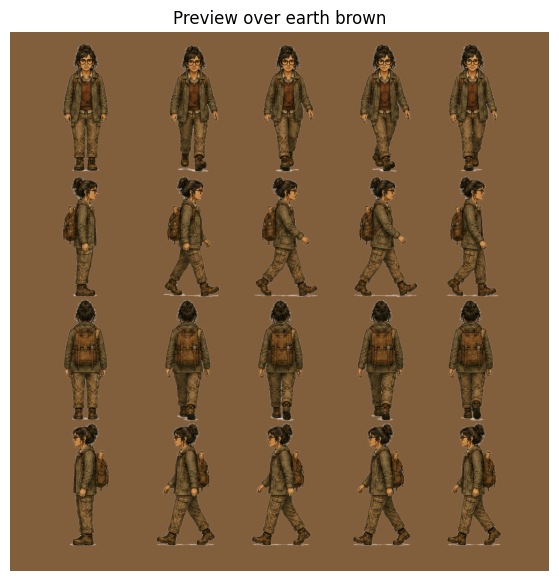

In [33]:
def composite_over_rgba(rgba, bg_rgb):
    a = rgba[..., 3:4].astype(np.float32) / 255.0
    fg = rgba[..., :3].astype(np.float32)
    bg = np.zeros_like(fg) + np.array(bg_rgb, dtype=np.float32)
    out = fg * a + bg * (1 - a)
    return out.astype(np.uint8)

test_backgrounds = {
    "dark gray": (40, 40, 40),
    "light gray": (210, 210, 210),
    "sky blue": (110, 170, 220),
    "earth brown": (130, 95, 60),
}

for name, bg in test_backgrounds.items():
    preview = composite_over_rgba(rgba_despill, bg)
    plt.figure(figsize=(14, 7))
    plt.imshow(preview)
    plt.title(f"Preview over {name}")
    plt.axis("off")
    plt.show()

## Save output

In [34]:
OUT_PATH = IMAGE_PATH.with_name(IMAGE_PATH.stem + "_extracted.png")
cv2.imwrite(str(OUT_PATH), cv2.cvtColor(rgba_despill, cv2.COLOR_RGBA2BGRA))
print("Saved:", OUT_PATH.resolve())

Saved: /home/nhorro/workspace/chroma-key-removal/data/julia/julia_extracted.png


## What to look for when it fails

Typical symptoms and likely causes:

| Symptom | Likely cause | Parameter to inspect |
|---|---|---|
| Pink halo remains | background mask too conservative | increase `RGB_THRESHOLD`, `HUE_TOL`, or `DILATE_K` |
| Object edge is eaten | background mask too aggressive | decrease `RGB_THRESHOLD`, `HUE_TOL`, or `DILATE_K` |
| Holes inside object | key color too close to object colors, or threshold too loose | lower thresholds, use conservative combined mask |
| Foliage looks damaged | key color conflicts with vegetation, or morphology too strong | avoid green key; lower morphology |
| Jagged edge | binary alpha or too little feathering | increase `FEATHER_PX` |
| Ghostly transparent edge | feathering too wide | decrease `FEATHER_PX` |
| Magenta contamination on border | anti-aliasing/despill issue | increase `DESPILL_STRENGTH`, slightly dilate background mask |